Dataset shape: (1661, 24)
         Study ID Patient ID          Sample ID  \
0  tmb_mskcc_2018  P-0000057  P-0000057-T01-IM3   
1  tmb_mskcc_2018  P-0000062  P-0000062-T01-IM3   
2  tmb_mskcc_2018  P-0000063  P-0000063-T01-IM3   
3  tmb_mskcc_2018  P-0000071  P-0000071-T01-IM3   
4  tmb_mskcc_2018  P-0000082  P-0000082-T01-IM3   

   Age at Which Sequencing was Reported (Days)  \
0                                         41.0   
1                                         80.0   
2                                         62.0   
3                                         66.0   
4                                         61.0   

  Age Group at Diagnosis in Years                 Cancer Type  \
0                           31-50               Breast Cancer   
1                             >71      Esophagogastric Cancer   
2                           61-70              Bladder Cancer   
3                           61-70              Bladder Cancer   
4                           50-60  Non-Sm

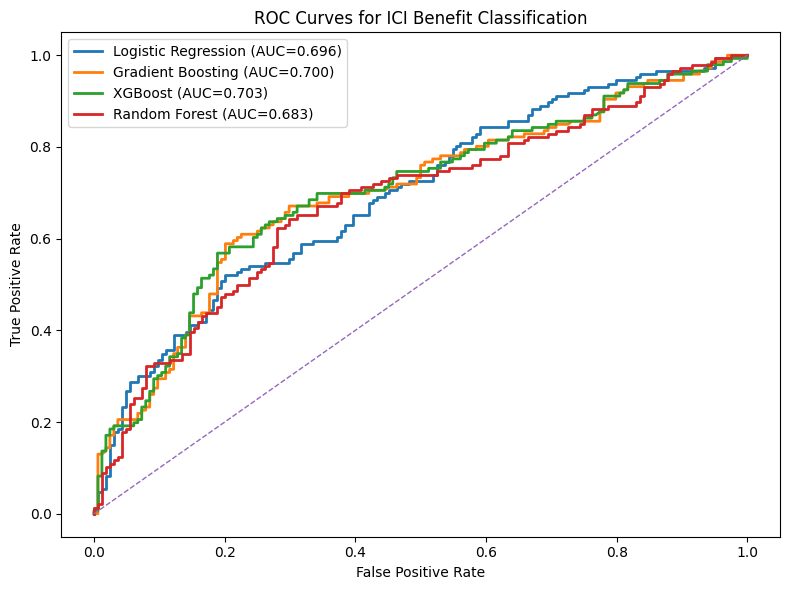


Global Feature Importance (SHAP Summary Plot):


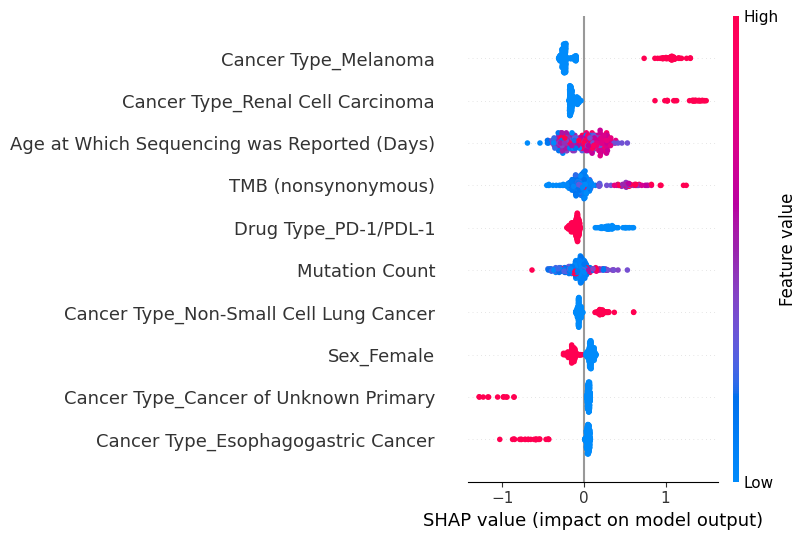

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NU

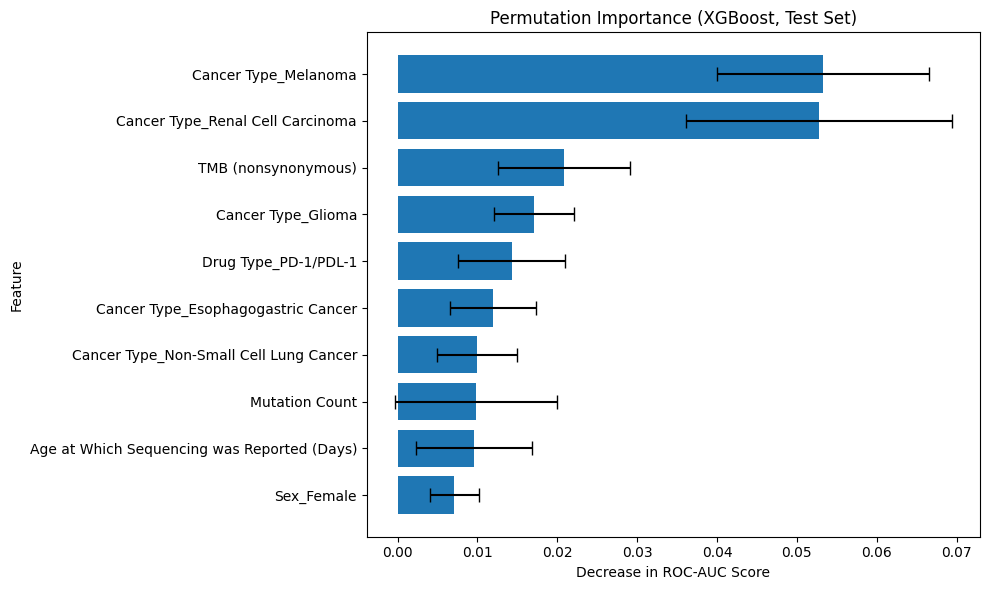


Partial Dependence Plots (Original Scale):


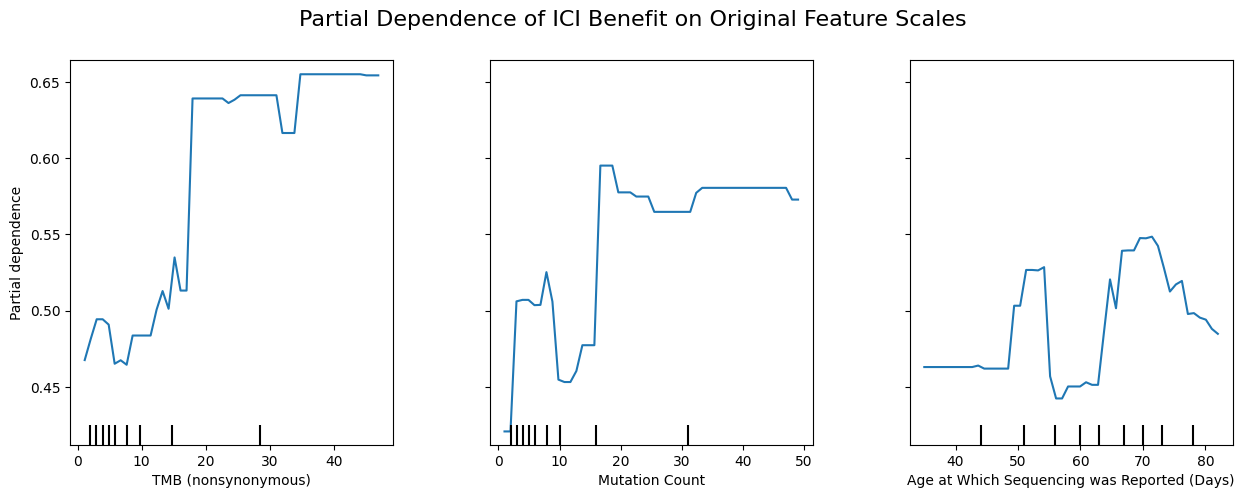

Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best Parameters Found: {'classifier__learning_rate': 0.01, 'classifier__max_depth': 3, 'classifier__n_estimators': 200}
Best CV ROC-AUC Score: 0.726


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    accuracy_score
)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

import xgboost as xgb

# ---- lifelines import patch for Python 3.9 ----
import datetime
if not hasattr(datetime, "UTC"):
    datetime.UTC = datetime.timezone.utc

from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import logrank_test

shap.initjs()

# ============================================================
# Helper: robust OneHotEncoder for different sklearn versions
# ============================================================
def make_ohe(drop=None):
    try:
        return OneHotEncoder(
            handle_unknown='ignore',
            drop=drop,
            sparse_output=False
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown='ignore',
            drop=drop,
            sparse=False
        )

# ============================================================
# 1. Load data
# ============================================================
RANDOM_STATE = 42
data_path = "tmb_mskcc_2018_clinical_data.tsv"

df = pd.read_table(data_path, sep='\t')
df.to_csv('tmb_mskcc_2018_clinical_data.csv', index=False)

print("Dataset shape:", df.shape)
print(df.head())

# ============================================================
# 2. Define features / targets
# ============================================================
numeric_features = [
    'Age at Which Sequencing was Reported (Days)',
    'Mutation Count',
    'TMB (nonsynonymous)',
    'Tumor Purity'
]

categorical_features = [
    'Cancer Type',
    'Drug Type',
    'Sex',
    'Sample Type'
]

target_col = 'Overall Survival (Months)'
status_col = 'Overall Survival Status'

# ============================================================
# 3. Basic type cleaning
# ============================================================
for col in numeric_features + [target_col]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

for col in categorical_features:
    df[col] = df[col].astype('category')

df['Event'] = (df[status_col] == '1:DECEASED').astype(int)

print("\nData types:")
print(df[numeric_features + categorical_features + [target_col, 'Event']].dtypes)

print("\nOverall Survival summary:")
print(df[target_col].describe())

print("\nOverall Survival summary among living patients:")
print(df[df[status_col] == '0:LIVING'][target_col].describe())

print("\nCancer Type counts:")
print(df['Cancer Type'].value_counts(dropna=False))

# ============================================================
# 4. Classification dataset (KEEP OLD LABEL)
# ============================================================
columns_to_check_cls = numeric_features + categorical_features + [target_col]
df_clean = df.dropna(subset=columns_to_check_cls).copy()

print(f"\nShape after dropping missing values for classification: {df_clean.shape}")

# OLD label definition exactly as you requested
df_clean['ICI_Benefit'] = (df_clean[target_col] >= 12.0).astype(int)

X = df_clean[numeric_features + categorical_features].copy()
y = df_clean['ICI_Benefit'].copy()

print("\nClass distribution for ICI Benefit:")
print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

# ============================================================
# 5. Classification preprocessing
#    - preserve your original style
#    - scaling numeric
#    - OHE categorical
# ============================================================
classification_preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('scaler', StandardScaler())
        ]), numeric_features),
        ('cat', Pipeline(steps=[
            ('onehot', make_ohe(drop=None))
        ]), categorical_features)
    ]
)

X_train_processed = classification_preprocessor.fit_transform(X_train)
X_test_processed = classification_preprocessor.transform(X_test)

cat_features_out = classification_preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_features)
feature_names = numeric_features + list(cat_features_out)

X_train_processed_df = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test.index)

print(f"\nTotal features after one-hot encoding (classification): {len(feature_names)}")

# ============================================================
# 6. Logistic Regression
# ============================================================
log_reg = LogisticRegression(
    penalty='l2',
    C=1.0,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    max_iter=1000
)

log_reg.fit(X_train_processed_df, y_train)

y_pred_lr = log_reg.predict(X_test_processed_df)
y_prob_lr = log_reg.predict_proba(X_test_processed_df)[:, 1]

print("\n--- Regularized Logistic Regression Performance ---")
print(classification_report(y_test, y_pred_lr))
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.3f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_lr):.3f}")

# ============================================================
# 7. Gradient Boosting
# ============================================================
gb_clf = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=RANDOM_STATE
)

gb_clf.fit(X_train_processed_df, y_train)

y_pred_gb = gb_clf.predict(X_test_processed_df)
y_prob_gb = gb_clf.predict_proba(X_test_processed_df)[:, 1]

print("\n--- Gradient Boosting Performance ---")
print(classification_report(y_test, y_pred_gb))
print(f"Accuracy: {accuracy_score(y_test, y_pred_gb):.3f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_gb):.3f}")

# ============================================================
# 8. XGBoost
# ============================================================
neg_class_count = (y_train == 0).sum()
pos_class_count = (y_train == 1).sum()
scale_pos_weight = neg_class_count / pos_class_count if pos_class_count > 0 else 1.0

xgb_clf = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    eval_metric='logloss'
)

xgb_clf.fit(X_train_processed_df, y_train)

y_pred_xgb = xgb_clf.predict(X_test_processed_df)
y_prob_xgb = xgb_clf.predict_proba(X_test_processed_df)[:, 1]

print("\n--- XGBoost Performance ---")
print(classification_report(y_test, y_pred_xgb))
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.3f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_xgb):.3f}")

# ============================================================
# 9. Random Forest
# ============================================================
rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    class_weight='balanced',
    random_state=RANDOM_STATE
)

rf_clf.fit(X_train_processed_df, y_train)

y_pred_rf = rf_clf.predict(X_test_processed_df)
y_prob_rf = rf_clf.predict_proba(X_test_processed_df)[:, 1]

print("\n--- Random Forest Performance ---")
print(classification_report(y_test, y_pred_rf))
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_rf):.3f}")

# ============================================================
# 10. ROC Curves
# ============================================================
plt.figure(figsize=(8, 6))

for name, probs in [
    ("Logistic Regression", y_prob_lr),
    ("Gradient Boosting", y_prob_gb),
    ("XGBoost", y_prob_xgb),
    ("Random Forest", y_prob_rf),
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_val = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={auc_val:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for ICI Benefit Classification")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 11. SHAP summary plot for XGBoost
# ============================================================
explainer = shap.TreeExplainer(xgb_clf)
shap_values = explainer.shap_values(X_test_processed_df)

print("\nGlobal Feature Importance (SHAP Summary Plot):")
shap.summary_plot(shap_values, X_test_processed_df, max_display=10)

# ============================================================
# 12. Permutation importance for XGBoost
# ============================================================
result = permutation_importance(
    xgb_clf,
    X_test_processed_df,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scoring='roc_auc'
)

perm_imp_df = pd.DataFrame({
    'Feature': X_test_processed_df.columns,
    'Importance_Mean': result.importances_mean,
    'Importance_Std': result.importances_std
})

perm_imp_df_top10 = perm_imp_df.sort_values(by='Importance_Mean', ascending=True).tail(10)

plt.figure(figsize=(10, 6))
plt.barh(
    perm_imp_df_top10['Feature'],
    perm_imp_df_top10['Importance_Mean'],
    xerr=perm_imp_df_top10['Importance_Std'],
    capsize=5
)
plt.title('Permutation Importance (XGBoost, Test Set)')
plt.xlabel('Decrease in ROC-AUC Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# ============================================================
# 13. Partial Dependence Plots on original feature scale
# ============================================================
full_xgb_pipeline = Pipeline(steps=[
    ('preprocessor', classification_preprocessor),
    ('classifier', xgb.XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        eval_metric='logloss'
    ))
])

full_xgb_pipeline.fit(X_train, y_train)

top_pdp_features = [
    'TMB (nonsynonymous)',
    'Mutation Count',
    'Age at Which Sequencing was Reported (Days)'
]

print("\nPartial Dependence Plots (Original Scale):")
fig, ax = plt.subplots(figsize=(15, 5))
PartialDependenceDisplay.from_estimator(
    full_xgb_pipeline,
    X_train,
    top_pdp_features,
    kind='average',
    ax=ax,
    grid_resolution=50
)
plt.subplots_adjust(wspace=0.3)
fig.suptitle('Partial Dependence of ICI Benefit on Original Feature Scales', fontsize=16)
plt.show()

# ============================================================
# 14. Hyperparameter tuning for XGBoost
# ============================================================
param_grid = {
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__n_estimators': [100, 200]
}

tuning_pipeline = Pipeline(steps=[
    ('preprocessor', classification_preprocessor),
    ('classifier', xgb.XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        eval_metric='logloss'
    ))
])

grid_search = GridSearchCV(
    estimator=tuning_pipeline,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nBest Parameters Found: {grid_search.best_params_}")
print(f"Best CV ROC-AUC Score: {grid_search.best_score_:.3f}")

best_xgb_model = grid_search.best_estimator_

In [2]:
df_clean['Drug Type'].value_counts()

Drug Type
PD-1/PDL-1    1219
Combo          238
CTLA4           90
Name: count, dtype: int64

In [3]:
# 6 months 
df_clean.columns

Index(['Study ID', 'Patient ID', 'Sample ID',
       'Age at Which Sequencing was Reported (Days)',
       'Age Group at Diagnosis in Years', 'Cancer Type',
       'Cancer Type Detailed', 'Drug Type', 'Gene Panel', 'Institute Source',
       'Metastatic Site', 'Mutation Count', 'Oncotree Code',
       'Overall Survival (Months)', 'Overall Survival Status',
       'Primary Tumor Site', 'Sample Class', 'Number of Samples Per Patient',
       'Sample coverage', 'Sample Type', 'Sex', 'Somatic Status',
       'TMB (nonsynonymous)', 'Tumor Purity', 'Event', 'ICI_Benefit'],
      dtype='object')

# Survival

In [4]:
columns_to_check_surv = numeric_features + categorical_features + [target_col, status_col]
df_surv = df.dropna(subset=columns_to_check_surv).copy()

y_surv = df_surv[[target_col, 'Event']].copy()
y_surv.columns = ['Time', 'Event']

X_surv = df_surv[numeric_features + categorical_features].copy()

X_train_surv, X_test_surv, y_train_surv, y_test_surv = train_test_split(
    X_surv,
    y_surv,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_surv['Event']
)

# reset indices so plotting labels align cleanly
X_train_surv = X_train_surv.reset_index(drop=True)
X_test_surv = X_test_surv.reset_index(drop=True)
y_train_surv = y_train_surv.reset_index(drop=True)
y_test_surv = y_test_surv.reset_index(drop=True)

In [5]:
columns_to_check_surv = numeric_features + categorical_features + [target_col, status_col]
df_surv = df.dropna(subset=columns_to_check_surv).copy()

y_surv = df_surv[[target_col, 'Event']].copy()
y_surv.columns = ['Time', 'Event']

X_surv = df_surv[numeric_features + categorical_features].copy()

X_train_surv, X_test_surv, y_train_surv, y_test_surv = train_test_split(
    X_surv,
    y_surv,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_surv['Event']
)

# reset indices so plotting labels align cleanly
X_train_surv = X_train_surv.reset_index(drop=True)
X_test_surv = X_test_surv.reset_index(drop=True)
y_train_surv = y_train_surv.reset_index(drop=True)
y_test_surv = y_test_surv.reset_index(drop=True)

In [6]:
survival_preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median'))
        ]), numeric_features),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', make_ohe(drop='first'))
        ]), categorical_features)
    ]
)

X_train_surv_proc = survival_preprocessor.fit_transform(X_train_surv)
X_test_surv_proc = survival_preprocessor.transform(X_test_surv)

surv_cat_features_out = survival_preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_features)
surv_feature_names = numeric_features + list(surv_cat_features_out)

X_train_surv_proc = pd.DataFrame(X_train_surv_proc, columns=surv_feature_names)
X_test_surv_proc = pd.DataFrame(X_test_surv_proc, columns=surv_feature_names)

print(f"\nSurvival Training Features Shape: {X_train_surv_proc.shape}")
print(f"Survival Testing Features Shape:  {X_test_surv_proc.shape}")


Survival Training Features Shape: (1237, 17)
Survival Testing Features Shape:  (310, 17)


In [7]:
train_df_lifelines = X_train_surv_proc.copy()
train_df_lifelines['Time'] = y_train_surv['Time'].values
train_df_lifelines['Event'] = y_train_surv['Event'].astype(int).values

test_df_lifelines = X_test_surv_proc.copy()
test_df_lifelines['Time'] = y_test_surv['Time'].values
test_df_lifelines['Event'] = y_test_surv['Event'].astype(int).values

print(f"\nLifelines Training Data Shape: {train_df_lifelines.shape}")
print(f"Lifelines Testing Data Shape:  {test_df_lifelines.shape}")

# ============================================================
# 18. Fit CoxPH
# ============================================================
cph = CoxPHFitter(penalizer= 0.01)
cph.fit(train_df_lifelines, duration_col='Time', event_col='Event')

c_index_cph_train = cph.score(train_df_lifelines, scoring_method="concordance_index")
c_index_cph_test = cph.score(test_df_lifelines, scoring_method="concordance_index")

print("\n--- Cox Proportional Hazards (CoxPH) ---")
print(f"Training C-index: {c_index_cph_train:.3f}")
print(f"Testing C-index:  {c_index_cph_test:.3f}")


Lifelines Training Data Shape: (1237, 19)
Lifelines Testing Data Shape:  (310, 19)

--- Cox Proportional Hazards (CoxPH) ---
Training C-index: 0.664
Testing C-index:  0.646


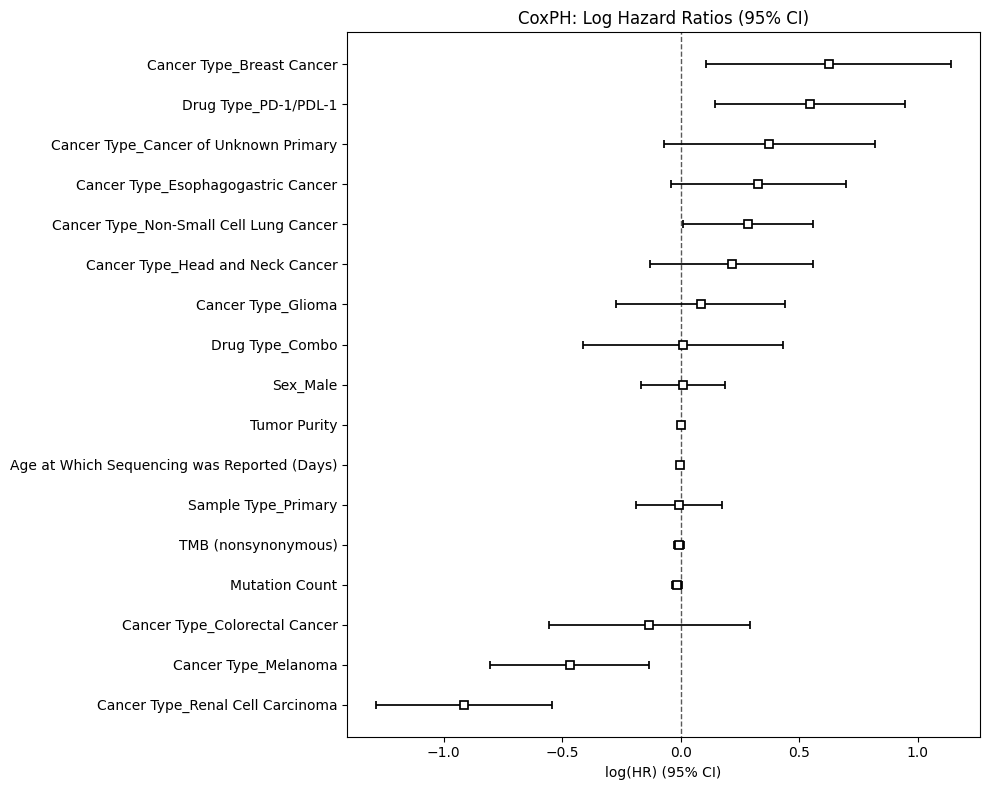

In [8]:
plt.figure(figsize=(10, 8))
cph.plot()
plt.title('CoxPH: Log Hazard Ratios (95% CI)')
plt.tight_layout()
plt.show()

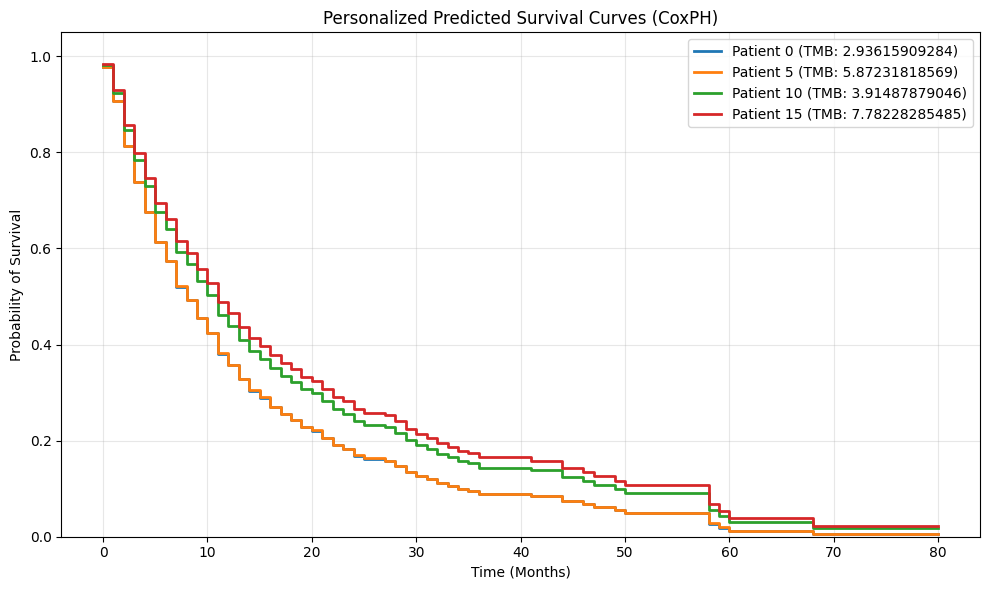

In [9]:
patient_positions = [0, 5, 10, 15]
patient_positions = [i for i in patient_positions if i < len(test_df_lifelines)]

X_patients_cph = test_df_lifelines.iloc[patient_positions].drop(columns=['Time', 'Event'])
surv_funcs_cph = cph.predict_survival_function(X_patients_cph)

plt.figure(figsize=(10, 6))
for i, pos in enumerate(patient_positions):
    tmb_val = X_test_surv.loc[pos, 'TMB (nonsynonymous)']
    plt.step(
        surv_funcs_cph.index,
        surv_funcs_cph.iloc[:, i],
        where="post",
        lw=2,
        label=f"Patient {pos} (TMB: {tmb_val})"
    )

plt.title('Personalized Predicted Survival Curves (CoxPH)')
plt.xlabel('Time (Months)')
plt.ylabel('Probability of Survival')
plt.ylim([0, 1.05])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Generating Kaplan-Meier Curve for TMB...


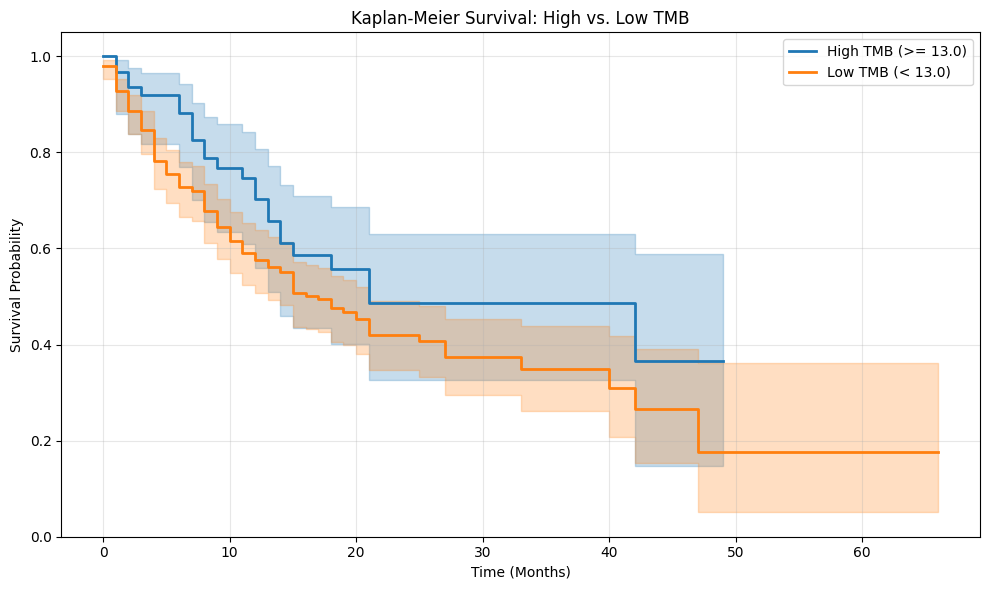

Log-rank p-value (High vs. Low TMB): 0.0751

Generating Partial Effects Plot for TMB...


<Figure size 1000x600 with 0 Axes>

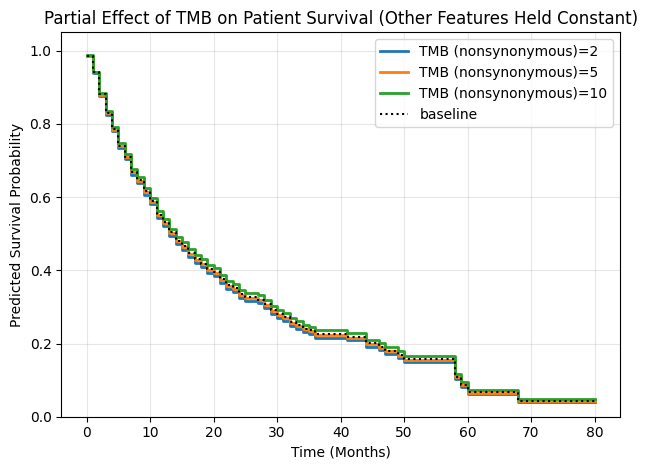

In [10]:
print("\nGenerating Kaplan-Meier Curve for TMB...")

kmf = KaplanMeierFitter()

if 'TMB (nonsynonymous)' not in test_df_lifelines.columns:
    raise ValueError("TMB (nonsynonymous) is not in test_df_lifelines. It must remain in the Cox dataset for TMB plots.")

tmb_threshold = test_df_lifelines['TMB (nonsynonymous)'].quantile(0.80)

mask_high_tmb = test_df_lifelines['TMB (nonsynonymous)'] >= tmb_threshold
mask_low_tmb = test_df_lifelines['TMB (nonsynonymous)'] < tmb_threshold

plt.figure(figsize=(10, 6))

kmf.fit(
    durations=test_df_lifelines.loc[mask_high_tmb, 'Time'],
    event_observed=test_df_lifelines.loc[mask_high_tmb, 'Event'],
    label=f'High TMB (>= {tmb_threshold:.1f})'
)
kmf.plot_survival_function(lw=2)

kmf.fit(
    durations=test_df_lifelines.loc[mask_low_tmb, 'Time'],
    event_observed=test_df_lifelines.loc[mask_low_tmb, 'Event'],
    label=f'Low TMB (< {tmb_threshold:.1f})'
)
kmf.plot_survival_function(lw=2)

plt.title('Kaplan-Meier Survival: High vs. Low TMB')
plt.xlabel('Time (Months)')
plt.ylabel('Survival Probability')
plt.ylim([0, 1.05])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

logrank_result = logrank_test(
    test_df_lifelines.loc[mask_high_tmb, 'Time'],
    test_df_lifelines.loc[mask_low_tmb, 'Time'],
    event_observed_A=test_df_lifelines.loc[mask_high_tmb, 'Event'],
    event_observed_B=test_df_lifelines.loc[mask_low_tmb, 'Event']
)

print(f"Log-rank p-value (High vs. Low TMB): {logrank_result.p_value:.4g}")

# ============================================================
# 22. Partial effects plot for TMB
#     Since numeric features were not scaled in survival preprocessing,
#     these values remain interpretable in original TMB units.
# ============================================================
print("\nGenerating Partial Effects Plot for TMB...")

tmb_values_to_simulate = [2, 5, 10]

plt.figure(figsize=(10, 6))
cph.plot_partial_effects_on_outcome(
    covariates='TMB (nonsynonymous)',
    values=tmb_values_to_simulate,
    lw=2
)

plt.title('Partial Effect of TMB on Patient Survival (Other Features Held Constant)')
plt.xlabel('Time (Months)')
plt.ylabel('Predicted Survival Probability')
plt.ylim([0, 1.05])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


--- Clinical Decision Support Summary: Patient 0 ---
Predicted Median Survival: 8.0 months

Risk Category:             6 Months - 1 Year (Moderate Risk)
Clinical Interpretation:   Predicted median survival is intermediate-short (8.0 months).
Suggested Action (Review): Proceed with ICI, but schedule regular restaging scans to assess actual clinical response.


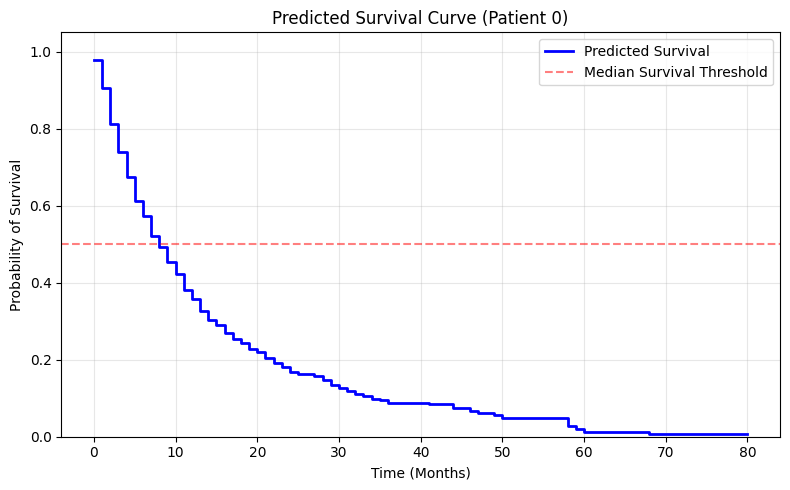

In [11]:
# ============================================================
# 20. Clinical Insights Framework (Corrected)
# ============================================================
from lifelines.utils import median_survival_times
import numpy as np

def generate_clinical_insight(median_survival_months, tmb_score):
    """
    A framework to translate ML survival predictions into Clinical Decision Support (CDS) insights.
    Stratified by custom timeframes: 0-3m, 3-6m, 6-12m, 1-3y, >3y.
    """
    insight = {
        "Time_Category": "Unknown",
        "Clinical_Interpretation": "",
        "Suggested_Action_for_Review": ""
    }
    
    # 1. Stratify based on Median Survival
    # Check if median survival is NaN or Infinity (meaning the survival curve never drops below 50%)
    if pd.isna(median_survival_months) or median_survival_months == np.inf:
        insight["Time_Category"] = "Indeterminate (Median not reached)"
        insight["Clinical_Interpretation"] = "Model could not calculate a median survival (curve does not drop below 50%). Patient likely has a favorable, long-term prognosis."
        insight["Suggested_Action_for_Review"] = "Standard clinical monitoring."
        
    elif median_survival_months < 3.0:
        insight["Time_Category"] = "0-3 Months (Extremely High Risk)"
        insight["Clinical_Interpretation"] = f"Predicted median survival is very short ({median_survival_months:.1f} months)."
        insight["Suggested_Action_for_Review"] = "Urgent tumor board review. Consider clinical trials, alternative therapies, or palliative care pathways."
        
    elif 3.0 <= median_survival_months < 6.0:
        insight["Time_Category"] = "3-6 Months (High Risk)"
        insight["Clinical_Interpretation"] = f"Predicted median survival is short ({median_survival_months:.1f} months)."
        insight["Suggested_Action_for_Review"] = "High-frequency monitoring recommended. Assess early response markers rigorously."
        
    elif 6.0 <= median_survival_months < 12.0:
        insight["Time_Category"] = "6 Months - 1 Year (Moderate Risk)"
        insight["Clinical_Interpretation"] = f"Predicted median survival is intermediate-short ({median_survival_months:.1f} months)."
        insight["Suggested_Action_for_Review"] = "Proceed with ICI, but schedule regular restaging scans to assess actual clinical response."
        
    elif 12.0 <= median_survival_months < 36.0:
        insight["Time_Category"] = "1 - 3 Years (Low Risk)"
        insight["Clinical_Interpretation"] = f"Predicted median survival is intermediate-long ({median_survival_months:.1f} months)."
        insight["Suggested_Action_for_Review"] = "Strong likelihood of ICI benefit. Proceed with standard clinical pathway."
        
    else:
        # >= 36.0 months
        insight["Time_Category"] = "> 3 Years (Long-term Responder)"
        insight["Clinical_Interpretation"] = f"Predicted median survival is highly favorable ({median_survival_months:.1f} months)."
        insight["Suggested_Action_for_Review"] = "Excellent expected response. Standard follow-up intervals."

    # 2. Add specific molecular flags (e.g., based on TMB)
    if tmb_score >= 10.0:
        insight["Clinical_Interpretation"] += " High TMB detected (>=10), which is traditionally associated with a better ICI response."

    return insight


# Select a single patient for clinical interpretation (e.g., Patient 0 from the test set)
patient_idx = 0

# Use X_test_surv_proc directly (it already contains only the features, no Time/Event columns)
single_patient_X = X_test_surv_proc.iloc[[patient_idx]]

# Extract TMB score for the clinical insight function
patient_tmb = single_patient_X['TMB (nonsynonymous)'].values[0]

# Extract Survival Function 
sf = cph.predict_survival_function(single_patient_X)

# Calculate median survival time 
med_time_calc = median_survival_times(sf)

# If it's a DataFrame, extract the number. If it's a float (like np.inf), just use it directly.
if isinstance(med_time_calc, pd.DataFrame):
    median_surv = med_time_calc.iloc[0, 0]
else:
    median_surv = float(med_time_calc)

print(f"\n--- Clinical Decision Support Summary: Patient {patient_idx} ---")
if np.isinf(median_surv) or pd.isna(median_surv):
    print("Predicted Median Survival: Not Reached (Curve remains above 50%)")
else:
    print(f"Predicted Median Survival: {median_surv:.1f} months")

# Generate the clinical interpretation
insights = generate_clinical_insight(
    median_survival_months=median_surv,
    tmb_score=patient_tmb
)

print("\nRisk Category:            ", insights["Time_Category"])
print("Clinical Interpretation:  ", insights["Clinical_Interpretation"])
print("Suggested Action (Review):", insights["Suggested_Action_for_Review"])

# Plot the patient's curve
plt.figure(figsize=(8, 5))
plt.step(sf.index, sf.iloc[:, 0], where="post", lw=2, label="Predicted Survival", color='blue')
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label="Median Survival Threshold")
plt.title(f"Predicted Survival Curve (Patient {patient_idx})")
plt.xlabel("Time (Months)")
plt.ylabel("Probability of Survival")
plt.ylim([0, 1.05])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# Select a single patient for clinical interpretation (e.g., Patient 0 from the test set)
patient_idx = 0

# --- ADD THIS TO SEE THE PATIENT'S ACTUAL PROFILE ---
patient_profile = X_test_surv.iloc[patient_idx]
print(f"\n--- Patient {patient_idx} True Clinical Profile ---")
print(f"Drug Type:   {patient_profile['Drug Type']}")
print(f"Cancer Type: {patient_profile['Cancer Type']}")
print(f"Sample Type: {patient_profile['Sample Type']}")
print(f"Age (Days):  {patient_profile['Age at Which Sequencing was Reported (Days)']}")
# ---------------------------------------------------

# Use X_test_surv_proc directly for the ML model
single_patient_X = X_test_surv_proc.iloc[[patient_idx]]


--- Patient 0 True Clinical Profile ---
Drug Type:   PD-1/PDL-1
Cancer Type: Non-Small Cell Lung Cancer
Sample Type: Metastasis
Age (Days):  47.0



--- Checking and Fixing Model Calibration ---


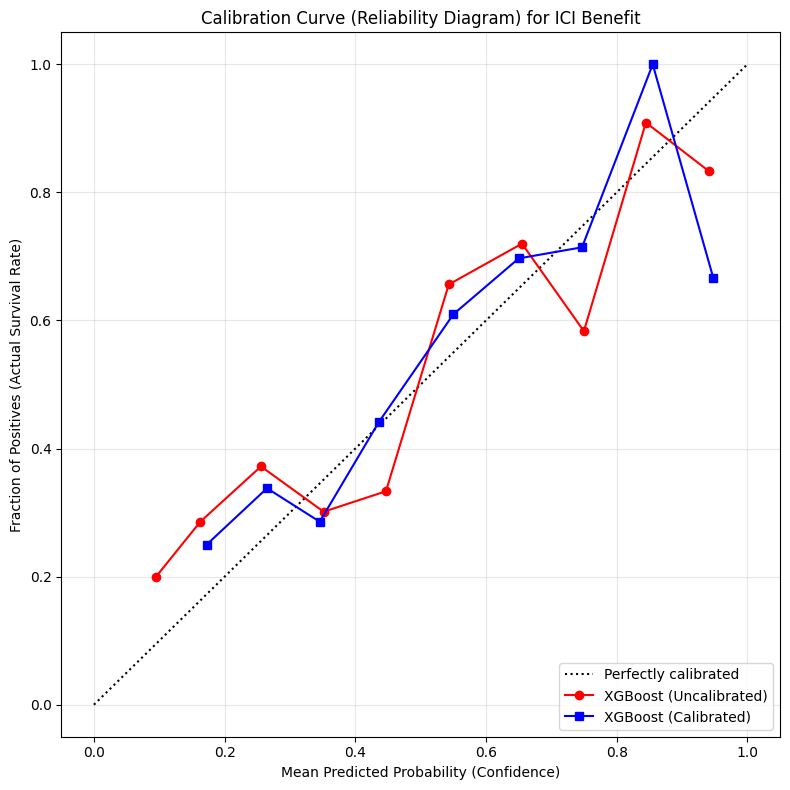

Brier Score (Uncalibrated): 0.2181
Brier Score (Calibrated):   0.2158

Conclusion: The calibration fix improved the reliability of your probabilities.
You should use 'y_prob_xgb_calibrated' for any downstream clinical decision support.


In [13]:
# ============================================================
# 24. Model Calibration Check (XGBoost)
# ============================================================
from sklearn.calibration import CalibrationDisplay, CalibratedClassifierCV

print("\n--- Checking and Fixing Model Calibration ---")

fig, ax = plt.subplots(figsize=(8, 8))

# Plot 1: The Perfectly Calibrated Reference Line
ax.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")

# Plot 2: Your Original XGBoost Model
CalibrationDisplay.from_predictions(
    y_test, 
    y_prob_xgb, 
    n_bins=10, 
    ax=ax, 
    name="XGBoost (Uncalibrated)",
    color='red',
    marker='o'
)

# ------------------------------------------------------------
# FIX: Train a calibrated version of your XGBoost model
# We use 'isotonic' regression which works well for tree-based models
# ------------------------------------------------------------
calibrated_xgb = CalibratedClassifierCV(xgb_clf, method='isotonic', cv=5)
calibrated_xgb.fit(X_train_processed_df, y_train)

# Get the new, calibrated probabilities
y_prob_xgb_calibrated = calibrated_xgb.predict_proba(X_test_processed_df)[:, 1]

# Plot 3: The Calibrated XGBoost Model
CalibrationDisplay.from_predictions(
    y_test, 
    y_prob_xgb_calibrated, 
    n_bins=10, 
    ax=ax, 
    name="XGBoost (Calibrated)",
    color='blue',
    marker='s'
)

plt.title("Calibration Curve (Reliability Diagram) for ICI Benefit")
plt.xlabel("Mean Predicted Probability (Confidence)")
plt.ylabel("Fraction of Positives (Actual Survival Rate)")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Compare the Brier Scores (lower is better for calibration)
from sklearn.metrics import brier_score_loss

brier_uncalibrated = brier_score_loss(y_test, y_prob_xgb)
brier_calibrated = brier_score_loss(y_test, y_prob_xgb_calibrated)

print(f"Brier Score (Uncalibrated): {brier_uncalibrated:.4f}")
print(f"Brier Score (Calibrated):   {brier_calibrated:.4f}")

if brier_calibrated < brier_uncalibrated:
    print("\nConclusion: The calibration fix improved the reliability of your probabilities.")
    print("You should use 'y_prob_xgb_calibrated' for any downstream clinical decision support.")
else:
    print("\nConclusion: Your original XGBoost model was already well-calibrated natively.")